# Uno Profile from Ledger claims analysis

Analyze the distribution of claims mined from issues by [build_claim_ledger_profile.py](./build_claim_ledger_profile.py)

In [1]:
import json
from pathlib import Path

ledger_path = Path("output/character-profile/uno/v8/final_ledger.json")
with ledger_path.open("r", encoding="utf-8") as f:
    ledger = json.load(f)

In [2]:
import pandas as pd

rows = []
for claim_id, claim in ledger["claims"].items():
    for supp in claim.get("supporting", []):
        rows.append(
            {
                "claim_id": claim_id,
                "claim_section": claim.get("section"),
                "scene_id": supp.get("scene_id"),
                "support": 1,
            }
        )
    for contr in claim.get("contradicting", []):
        rows.append(
            {
                "claim_id": claim_id,
                "claim_section": claim.get("section"),
                "scene_id": contr.get("scene_id"),
                "support": -1,
            }
        )

df = pd.DataFrame(rows)
df

,claim_id,claim_section,scene_id,support
0,1,identity,pkna-0_25,1
1,1,identity,pkna-0-2_29,1
2,1,identity,pkna-2_33,1
3,2,identity,pkna-0_25,1
4,2,identity,pkna-0_33,1
...,...,...,...,...
1820,195,relationships,pkna-49_10,1
1821,196,identity,pkna-49_32,1
1822,197,behavior,pkna-49_32,1
1823,198,identity,pkna-49_32,1


In [3]:
n_supporting = df.groupby("claim_id")["support"].apply(lambda x: (x == 1).sum())
n_supporting

claim_id
1       3
10     37
100     6
101    10
102     3
       ..
95     10
96      1
97      3
98      3
99      9
Name: support, Length: 199, dtype: int64

In [6]:
# Group supporting counts by section
supporting_by_section = {}
for section in df["claim_section"].unique():
    section_claims = (
        df[df["claim_section"] == section]
        .groupby("claim_id")["support"]
        .apply(lambda x: (x == 1).sum())
    )
    supporting_by_section[section] = section_claims

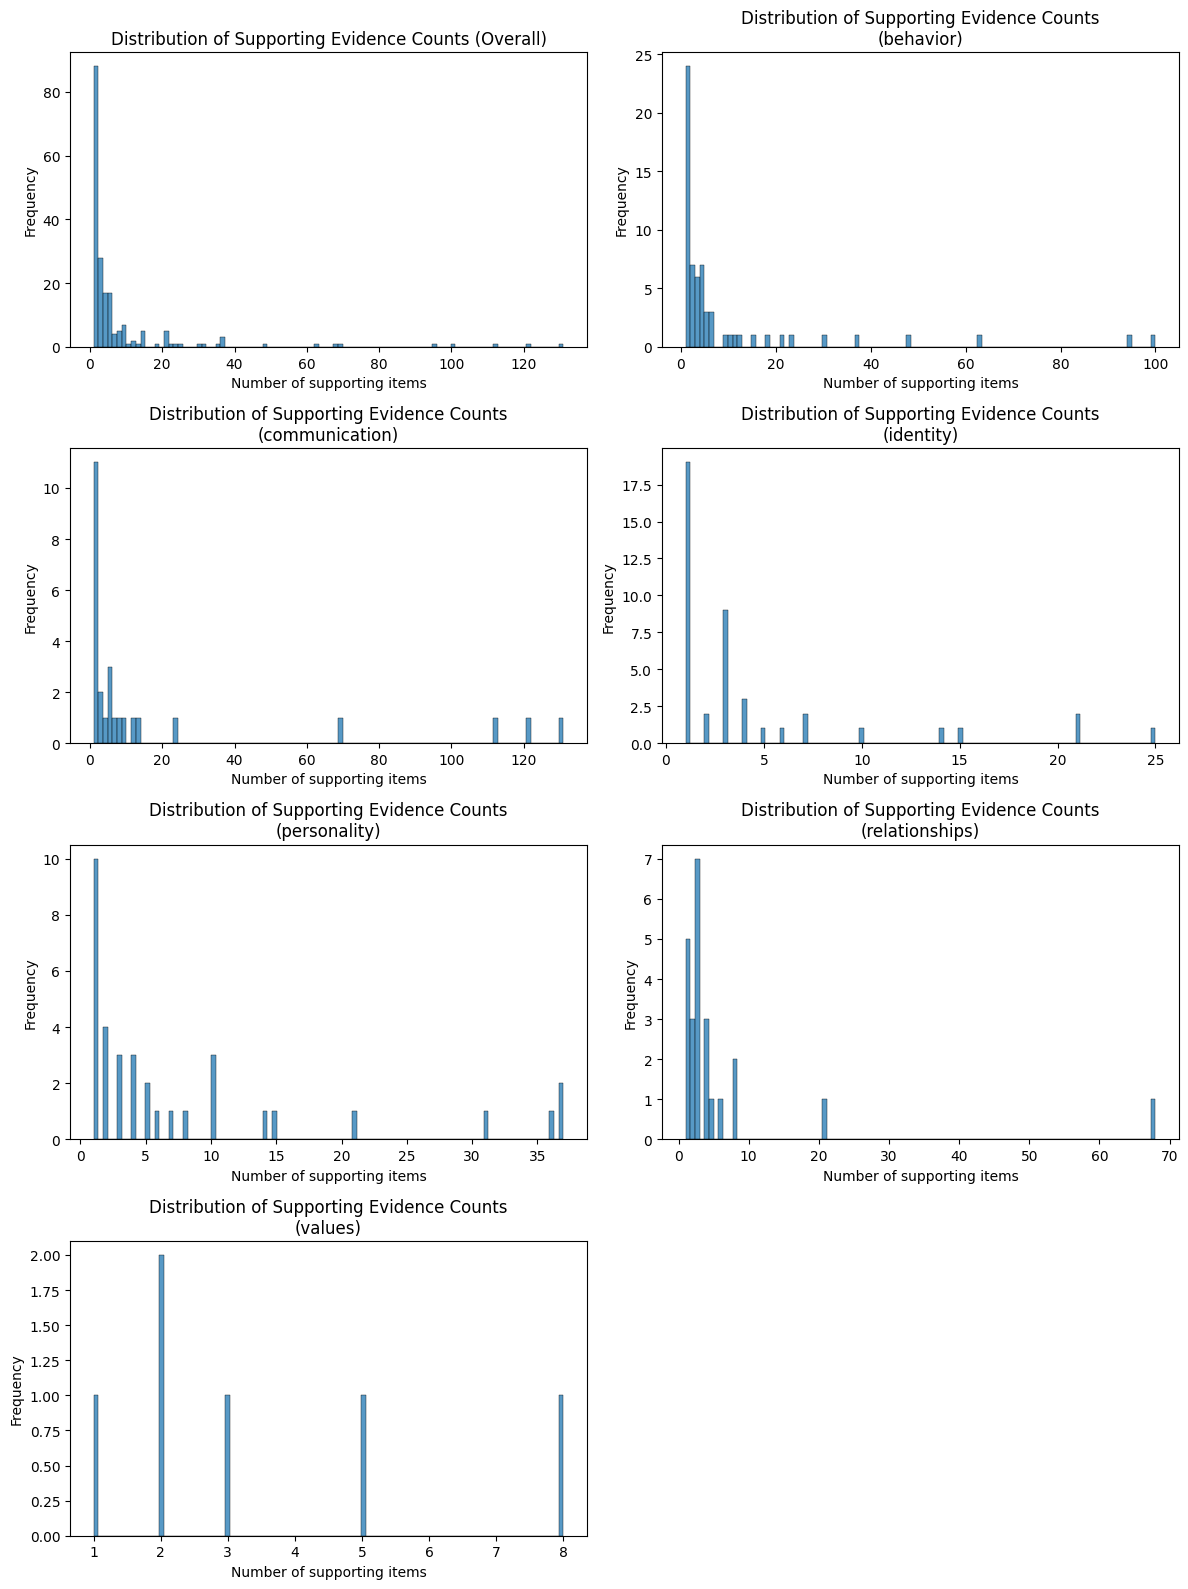

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create subplots: 1 for overall + 1 per section
n_sections = len(supporting_by_section)
n_rows = (n_sections + 2) // 2  # +1 for overall, then arrange in 2 columns
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

# Plot overall distribution
sns.histplot(n_supporting, bins=100, edgecolor="black", ax=axes[0])
axes[0].set_title("Distribution of Supporting Evidence Counts (Overall)")
axes[0].set_xlabel("Number of supporting items")
axes[0].set_ylabel("Frequency")

# Plot per-section distributions
for i, (section, counts) in enumerate(sorted(supporting_by_section.items()), start=1):
    sns.histplot(counts, bins=100, edgecolor="black", ax=axes[i])
    axes[i].set_title(f"Distribution of Supporting Evidence Counts\n({section})")
    axes[i].set_xlabel("Number of supporting items")
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots
for i in range(n_sections + 1, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()